In [1]:
import xarray as xr
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.colors as mcolors
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.lines as mlines

In [2]:
# Load data for all 3 model runs

runs = ['OWB', 'AOWB', 'HC']
region_keys = ['off_shelf', 'shelf_break_n', 'northsea', 'shelf_break_s']
regtitle = {'off_shelf':'Off Shelf',
            'shelf_break_n':'Shelf Break - North',
            'northsea':'North Sea',
            'shelf_break_s':'Shelf Break - South'}

regions = {'off_shelf':{'xsl':slice(200,300),'ysl':slice(1050,1150)},
           'shelf_break_n':{'xsl':slice(480,580),'ysl':slice(800,900)},
           'northsea':{'xsl':slice(900,1000),'ysl':slice(800,900)},
           'shelf_break_s':{'xsl':slice(450,550),'ysl':slice(175,275)}}

run_paths = {
    'AOWB' : '/gws/pw/j25/rep/omerrett/AOWB_RALP3P3_fixes/Analysis/annual_temp/hovmuller/',
    'OWB' : '/gws/pw/j25/rep/omerrett/OWB/Analysis/annual_temp/hovmuller/',
    'HC' : '/gws/pw/j25/rep/omerrett/AOW-24_year_hindcast/temp_hovmuller/regional/'
}

phy_data = {run : {} for run in runs}

for run in runs:
    for region in region_keys:
        file_path = f"{run_paths[run]}{region}/annual.nc"

        if os.path.exists(file_path):
            phy_data[run][region] = xr.open_dataset(file_path)
        else:
            print(f"Warning: File missing for {run} - {region}")

print (" Datasets loaded for runs:", list(phy_data.keys()))

 Datasets loaded for runs: ['OWB', 'AOWB', 'HC']


In [3]:
# Add depth from the grid mesh mask

grd = xr.open_dataset("/home/users/omerrett/mesh_mask.nc").isel(t=0).rename({'z':'deptht'})

region_depths = {}

# Compute average depth for the region
for reg in regions:
    xsl = regions[reg]['xsl']
    ysl = regions[reg]['ysl']
    e3t = grd.e3t_0.isel(y=ysl,x=xsl).mean(['x','y']) 
    depth = -1*grd.gdept_0.isel(x=xsl,y=ysl).mean(['x','y']).values
    region_depths[reg] = depth

for run in ['OWB', 'AOWB','HC']:
    for region in region_keys:
        
        # Assign the calculated meters to the 'deptht' coordinate
        phy_data[run][region] = phy_data[run][region].assign_coords(
            deptht=region_depths[region]
        )

In [4]:
# Calculate the difference between model runs

# This does several possibilities depending on preferences on data visualisation
phy_data['AOWB - OWB'] = {}
phy_data['AOWB - HC'] = {}
phy_data['OWB - HC'] = {}
phy_data['HC - OWB'] = {}

for region in region_keys:
    if region in phy_data['AOWB'] and region in phy_data['OWB']:
         
        a = phy_data['AOWB'][region]
        o = phy_data['OWB'][region]
        h = phy_data['HC'][region]

        a.coords['time_counter'] = a.time_counter.dt.floor('D')
        o.coords['time_counter'] = o.time_counter.dt.floor('D')
        h.coords['time_counter'] = h.time_counter.dt.floor('D')


        a_aligned, o_aligned, h_aligned = xr.align(a, o, h, join='inner')
        
        phy_data['AOWB - OWB'][region] = a_aligned - o_aligned
        phy_data['AOWB - HC'][region] = a_aligned - h_aligned
        phy_data['OWB - HC'][region] = o_aligned - h_aligned
        phy_data['HC - OWB'][region] = h_aligned - o_aligned
        
    else:
        print( f" Warning: Could not calculate difference for {region} due to missing file.")


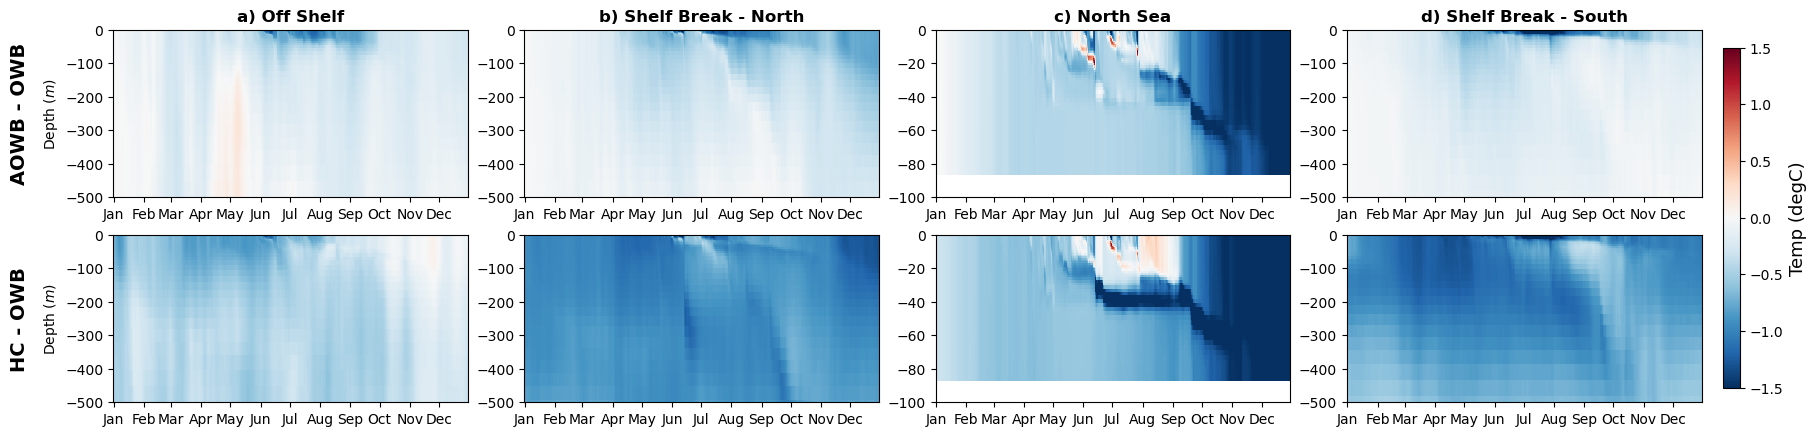

In [6]:
title = 'Temperature'

fig, axes = plt.subplots(2, 4, figsize=(17, 4.25), sharey=False, layout = 'constrained')

vmin = 7
vmax = 17

region_keys = ['off_shelf', 'shelf_break_n','northsea', 'shelf_break_s']

runs = ['AOWB - OWB', 'HC - OWB']

plot_label = ['a)','b)','c)','d)']

vmax = 1.5
for i, run in enumerate(runs):
    for j, region in enumerate(region_keys):
        ax = axes[i, j]
        im_diff = phy_data[run][region]['votemper'].plot(ax=ax,
                                                         x= 'time_counter',
                                                         y='deptht',
                                                         vmin = - vmax,
                                                         vmax = vmax, 
                                                         cmap = 'RdBu_r', 
                                                         add_colorbar = False)
           
        
            
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday = 2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

        
        if i ==0:
            ax.set_title(f"{plot_label[j]} {regtitle[region]}", fontweight = 'bold')
        ax.set_xlabel('')
        if region == 'northsea':
            ax.set_ylim(-100, 0)
        else:
            ax.set_ylim(-500,0)
        
        
        if j == 0:
            ax.set_ylabel('Depth ($m$)')

            ax.annotate(run, xy=(0, 0.5), xytext=(-ax.yaxis.labelpad - 5, 0),
                        xycoords=ax.yaxis.label, textcoords='offset points',
                        size=14, ha='right', va='center', fontweight='bold', rotation=90)
        else:
            ax.set_ylabel('')

        
        
cbar2_ax = fig.add_axes([1.01, 0.1, 0.01, 0.8])
cbar2 = fig.colorbar(im_diff, cax=cbar2_ax, orientation='vertical')
cbar2.set_label('Temp (degC)', fontsize=13)
cbar2.ax.tick_params(labelsize=10)

plt.savefig(f"{title} Hovmuller", dpi=600, bbox_inches='tight')